# The modified Okubo-Weiss parameter $W^*$ (Bachman 2021)

This notebook demonstrates the new `Wstar` field added to
`dbof.preprocessing.calculated_fields_at_depth.modified_okubo_weiss_3d`.

Like the classical Okubo-Weiss parameter $W=\sigma_n^2+\sigma_s^2-\omega^2$, $W^*$ compares strain and vorticity, but it is
additionally sensitive to the vertical shear carried by the
quasigeostrophic $Q$ vector:

$$W^* = 4\,\mathrm{sgn}(l_2)\,\sqrt{l_1^2+l_2^2},\qquad
l_2=\tfrac14 W,\qquad
l_1=\tfrac12 l_2+\tfrac12\sqrt{l_2^2+|Q|^2/f^2}$$

with $Q_1=-(\partial_x u\,\partial_x b+\partial_x v\,\partial_y b)$, $Q_2=-(\partial_y u\,\partial_x b+\partial_y v\,\partial_y b)$ and $|Q|^2=Q_1^2+Q_2^2$.

The buoyancy gradient $\nabla_h b$ uses the unscaled physical
buoyancy $b=(g/\rho_0)\rho$ (the same convention as $N^2$ and the
balanced Richardson number), so $W^*$ comes out in $\mathrm{s}^{-2}$,
the same units as the classical $W$.

In [1]:
%matplotlib inline
from IPython.display import display
import numpy as np
import dask.array as da
import xarray as xr
import matplotlib.pyplot as plt

import dbof.preprocessing.calculated_fields_at_depth as cfad
from dbof.preprocessing.physical_constants import OMEGA_EARTH

## Part 1 — Formula demo on synthetic data (offline)

`modified_okubo_weiss_3d` accepts the classical Okubo-Weiss field
`okubo_weiss` (=$W$) and the QG forcing `q_squared` (=$|Q|^2$)
through keywords, so we can exercise the closed-form combination
without standing up an xgcm grid (only latitude `YC` is needed, for
$f$).  This is the same injection pattern the unit tests use.

In [2]:
# A small synthetic tile at 30 deg N carrying only latitude YC
# (all that the Coriolis parameter needs).
lat = 30.0
shape = (1, 1, 1)
ds_merge = xr.Dataset(
    {'YC': (('face', 'j', 'i'), np.full(shape, lat))})
f = 2.0 * OMEGA_EARTH * np.sin(np.deg2rad(lat))
print(f'Coriolis f at {lat} N = {f:.3e} s^-1')

Coriolis f at 30.0 N = 7.292e-05 s^-1


In [3]:
# Sweep the Okubo-Weiss parameter from vorticity-dominated (W<0)
# to strain-dominated (W>0), for several QG-forcing strengths.
W = np.linspace(-4e-9, 4e-9, 401)            # s^-2
# Express |Q|^2 via the dimensionless ratio r = (|Q|/f) / |l2_ref|,
# i.e. |Q|^2/f^2 = (r * |W_ref|/4)^2, with W_ref = 4e-9.
l2_ref = 4e-9 / 4.0
ratios = [0.0, 1.0, 3.0]                      # shear strength knob

def wstar_curve(W_arr, qsq_scalar):
    '''W* for a 1-D sweep of W at fixed |Q|^2 (uses the field fn).'''
    da_W = xr.DataArray(
        da.from_array(W_arr.reshape(1, 1, -1)), dims=('face','j','i'))
    da_q = xr.DataArray(
        da.from_array(np.full((1,1,W_arr.size), qsq_scalar)),
        dims=('face','j','i'))
    ds = xr.Dataset({'YC': (('face','j','i'),
                            np.full((1,1,W_arr.size), lat))})
    out = cfad.modified_okubo_weiss_3d(
        ds, grid=None, okubo_weiss=da_W, q_squared=da_q)
    return out.values.ravel()

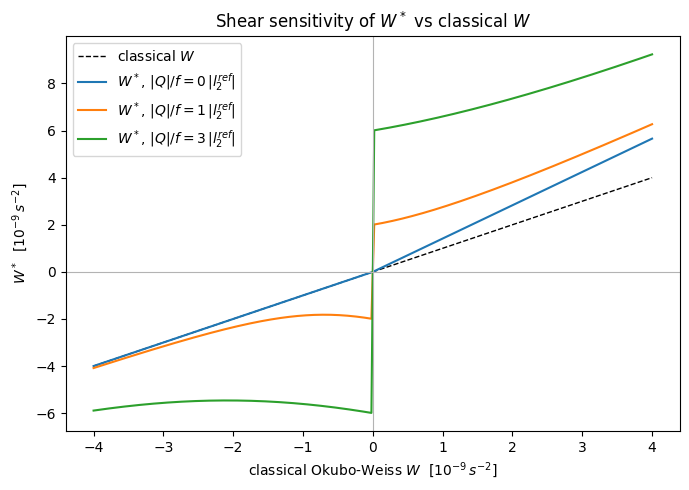

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(W * 1e9, W * 1e9, 'k--', lw=1, label='classical $W$')
for r in ratios:
    qsq = (r * l2_ref) ** 2 * f ** 2          # |Q|^2 = (r l2_ref)^2 f^2
    ws = wstar_curve(W, qsq)
    ax.plot(W * 1e9, ws * 1e9,
            label=f'$W^*$, $|Q|/f={r:g}\\,|l_2^{{ref}}|$')
ax.axhline(0, color='0.7', lw=0.8)
ax.axvline(0, color='0.7', lw=0.8)
ax.set_xlabel('classical Okubo-Weiss $W$  [$10^{-9}\\,s^{-2}$]')
ax.set_ylabel('$W^*$  [$10^{-9}\\,s^{-2}$]')
ax.set_title('Shear sensitivity of $W^*$ vs classical $W$')
ax.legend()
fig.tight_layout()

Notes from the curves:

* With **no shear** ($|Q|^2=0$) the vorticity-dominated branch
  ($W<0$) collapses exactly onto the classical $W$, while the
  strain-dominated branch ($W>0$) is amplified by $\sqrt2$.
* Increasing the QG forcing $|Q|^2/f^2$ pushes $W^*$ upward — the
  modification makes the diagnostic more sensitive to frontal /
  vertical-shear structure than the classical parameter.
* The sign of $W^*$ always follows the sign of $W$ (via
  $\mathrm{sgn}(l_2)$).

## Part 2 — A real LLC4320 tile (requires network / S3)

This mirrors `tests/test_calculated_fields_at_depth.test_balanced_richardson_against_real_tile`: load one 720x720 tile,
build a single-face xgcm grid, compute the **surface** classical
Okubo-Weiss and $W^*$ via the production functions + `apply_depth_strategies`, and compare them.

It is wrapped in `try/except` so the notebook still runs end-to-end
offline (the cell simply reports that it was skipped).

In [5]:
def load_tile_surface_fields():
    '''Compute surface W and W* on one real LLC4320 tile.

    Returns (XC, YC, W_sfc, Wstar_sfc) as 2-D numpy arrays.
    Requires network access to the LLC4320 S3 store.
    '''
    import dbof.tiles.tile_utils as tu
    from dbof.tiles.tile_mapping import rect_ij_to_tile
    from dbof.llc4320_ingestion.grid import set_xgcm_grid
    from dbof.preprocessing.depth_strategies import \
        apply_depth_strategies

    s3 = tu._resolve_s3_source(None)
    timestamp = '2012-11-09 12:00:00'
    tile = rect_ij_to_tile(5000, 5000)        # open-ocean tile

    ds_grid = tu._load_grid_for_tile(s3, tile)
    # W* needs tracers (for b) AND velocities (for the Jacobian).
    ds_fields = tu._load_tracers_for_tile(
        s3, timestamp, tile,
        vars_needed=['Theta', 'Salt', 'U', 'V'])

    # Slice staggered dims to the tile extent for a clean single-face
    # grid.  The tracer loader slices only i/j, so U (on i_g) and V
    # (on j_g) keep full-width staggered dims — slice them here too so
    # every dimension is 720 and the merge is consistent.
    stag = {d: sl for d, sl in (('i_g', tile.i_face_slice),
                                ('j_g', tile.j_face_slice))
            if d in ds_grid.dims}
    ds_grid = ds_grid.isel(stag)
    ds_fields = ds_fields.isel(
        {d: sl for d, sl in stag.items() if d in ds_fields.dims})
    ds_merge = xr.merge([ds_grid, ds_fields])

    vvars = [v for v in ('Z','Zl','Zu','Zp1','drF') if v in ds_grid]
    grid = set_xgcm_grid(ds_grid.drop_vars(vvars),
                         use_connections=False)

    # Production 3-D fields, reduced to the surface.
    ow_3d = cfad.okubo_weiss_3d(ds_merge, grid)
    ws_3d = cfad.modified_okubo_weiss_3d(ds_merge, grid)
    ow = apply_depth_strategies(
        ow_3d, 'okubo_weiss', ds_merge, mld=None,
        requested={'okubo_weiss_sfc'})['okubo_weiss_sfc'].compute()
    ws = apply_depth_strategies(
        ws_3d, 'Wstar', ds_merge, mld=None,
        requested={'Wstar_sfc'})['Wstar_sfc'].compute()
    g2 = ds_grid.isel(face=0)
    return (g2['XC'].values, g2['YC'].values,
            ow.isel(face=0).values, ws.isel(face=0).values)

try:
    XC, YC, W_sfc, Wstar_sfc = load_tile_surface_fields()
    have_tile = True
except Exception as exc:        # offline / no S3 access
    have_tile = False
    print(f'Skipping real-tile demo (no network?): {exc!r}')

/home/xavier/Oceanography/python/llc4320-native-grid-preprocessing/src/dbof/llc4320_ingestion/get_raw_data.py:590: UserWarning: The specified chunks separate the stored chunks along dimension "k" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  grid = xr.open_zarr(
/home/xavier/Oceanography/python/llc4320-native-grid-preprocessing/src/dbof/llc4320_ingestion/get_raw_data.py:590: UserWarning: The specified chunks separate the stored chunks along dimension "k_l" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  grid = xr.open_zarr(


LLC_DEPTH grid file loaded from s3://dbof/LLC4320/grid.zarr.


/home/xavier/Oceanography/python/llc4320-native-grid-preprocessing/src/dbof/llc4320_ingestion/get_raw_data.py:412: UserWarning: The specified chunks separate the stored chunks along dimension "face" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(


LLC timestep data loaded: 20121109T12.zarr, vars=['Theta', 'Salt', 'U', 'V']


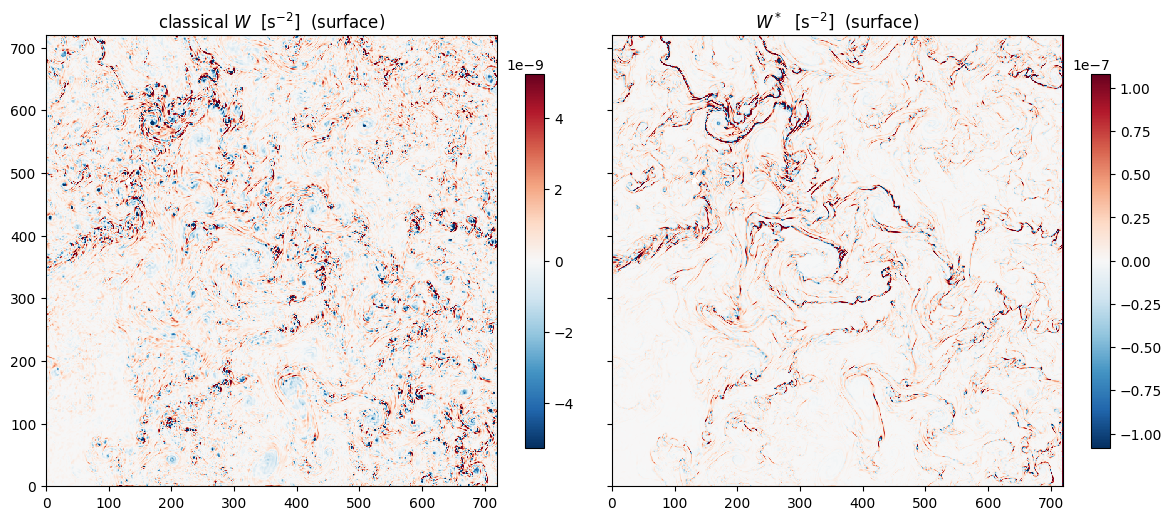

In [9]:
if have_tile:
    # Symmetric colour limits about zero for both panels.
    lim1 = np.nanquantile(np.abs(W_sfc), 0.99)
    lim2 = np.nanquantile(np.abs(Wstar_sfc), 0.99)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                             sharex=True, sharey=True)
    for ax, fld, ttl, lim in [(axes[0], W_sfc, 'classical $W$', lim1),
                          (axes[1], Wstar_sfc, '$W^*$', lim2)]:
        pcm = ax.pcolormesh(fld, cmap='RdBu_r',
                            vmin=-lim, vmax=lim)
        ax.set_title(f'{ttl}  [s$^{{-2}}$]  (surface)')
        ax.set_aspect('equal')
        fig.colorbar(pcm, ax=ax, shrink=0.8)
    fig.tight_layout()
    display(fig)        # explicit so it renders in any runner
    plt.close(fig)
else:
    print('Real-tile panels skipped (Part 2 needs network access).')

### Takeaways

* `Wstar` is wired into the **frontogenesis** subset (it reuses that
  subset's velocity Jacobian) and is registered in `dbof.defs.fields_dmodel` with units `s^-2`.
* Request it through any depth strategy, e.g. `Wstar_sfc`,
  `Wstar_z25m`, `Wstar_mld`, `Wstar_mld_mean`.
* Compared with the classical Okubo-Weiss parameter, $W^*$ enhances
  signal in vertically sheared / frontal regions through the QG
  $Q$-vector term.